In [2]:
import cobra
import pandas as pd
import numpy as np
from scipy.optimize import linprog
from scipy.stats import ttest_ind

from cobra.flux_analysis import pfba, flux_variability_analysis
from cobra.manipulation.delete import remove_genes, prune_unused_metabolites, prune_unused_reactions
from cobra.sampling import sample

import seaborn as sns
import matplotlib.pyplot as plt

In [121]:
# Load the SBML model
model = cobra.io.read_sbml_model(
    '/Users/karthik/Desktop/PHCCO IISc Internship/EMT/Recon3D.xml')
model

Name,Recon3D
Memory address,3577fc590
Number of metabolites,5835
Number of reactions,10600
Number of genes,2248
Number of groups,0
Objective expression,1.0*BIOMASS_maintenance - 1.0*BIOMASS_maintenance_reverse_5b3f9
Compartments,"cytosol, lysosome, mitochondria, endoplasmic reticulum, extracellular space, peroxisome/glyoxysome, nucleus, golgi apparatus, inner mitochondrial compartment"


In [3]:
# Check for essential metabolites and gaps in the model
summary = model.summary()
print(summary)

Objective
1.0 BIOMASS_maintenance = 755.003215550663

Uptake
------
  Metabolite        Reaction  Flux  C-Number C-Flux
     thmtp_c      DM_thmtp_c  1000        12  4.09%
  12ppd__R_e   EX_12ppd__R_e 250.8         3  0.26%
      5aop_e       EX_5aop_e  1000         5  1.70%
   HC00250_e    EX_HC00250_e  1000         0  0.00%
   HC00900_e    EX_HC00900_e  1000         4  1.36%
   HC01361_e    EX_HC01361_e  1000         9  3.07%
     Lkynr_e      EX_Lkynr_e 105.1        10  0.36%
   acetone_e    EX_acetone_e 427.7         3  0.44%
     alltn_e      EX_alltn_e  1000         4  1.36%
       atp_e        EX_atp_e  1000        10  3.41%
       cit_e        EX_cit_e 718.8         6  1.47%
    crm_hs_e     EX_crm_hs_e  1000        19  6.47%
      dcmp_e       EX_dcmp_e  1000         9  3.07%
      dopa_e       EX_dopa_e  1000         8  2.73%
      dtmp_e       EX_dtmp_e  1000        10  3.41%
gluside_hs_e EX_gluside_hs_e  13.2        25  0.11%
      h2o2_e       EX_h2o2_e  1000         0  0.

In [4]:
for i, reaction in enumerate(model.reactions):
    print(f"{i}. ID: {reaction.id} Rxn: {reaction.name}")

0. ID: 24_25DHVITD3tm Rxn: 24,25-Dihydroxyvitamin D3 transport from mitochondria
1. ID: 25HVITD3t Rxn: 25-hydroxyvitamin D3 transport from cytoplasm
2. ID: COAtl Rxn: CoA transport in lysosome via diffusion
3. ID: EX_5adtststerone_e Rxn: 5alpha-Dihydrotestosterone exchange
4. ID: EX_5adtststerones_e Rxn: 5alpha-Dihydrotestosterone sulfate exchange
5. ID: EX_5fthf_e Rxn: 5-Formyltetrahydrofolate exchange
6. ID: EX_5htrp_e Rxn: 5-Hydroxy-L-tryptophan exchange
7. ID: EX_5mthf_e Rxn: 5-Methyltetrahydrofolate exchange
8. ID: EX_5thf_e Rxn: Pentaglutamyl folate (THF) exchange
9. ID: EX_6dhf_e Rxn: Haxglutamyl folate (DHF) exchange
10. ID: 24_25VITD3Hm Rxn: 24R-Vitamin D-25-hydroxylase (D3)
11. ID: 24NPHte Rxn: Xenobiotic transport
12. ID: 10FTHF7GLUtl Rxn: 7-glutamyl-10FTHF transport, lysosomal
13. ID: 10FTHFtm Rxn: 10-Formyltetrahydrofolate mitochondrial transport via diffusion
14. ID: 11DOCRTSLtr Rxn: 11-deoxycortisol intracellular transport
15. ID: 13DAMPPOX Rxn: 1,3-Diaminopropane:oxygen

In [5]:
# Remove any unused metabolites or reactions
cobra.manipulation.delete.prune_unused_metabolites(model)

(<Model Recon3D at 0x3280d7790>, [])

In [6]:
print(model.objective)

Maximize
1.0*BIOMASS_maintenance - 1.0*BIOMASS_maintenance_reverse_5b3f9


In [7]:
solution = model.optimize()
solution.objective_value

755.0032155506632

## Processing the expression file `s11.xlsx`:

In [6]:
# Load the Excel file
file_path = '/Users/karthik/Desktop/PHCCO IISc Internship/EMT/s11.xlsx'
df = pd.read_excel(file_path)
df

,Symbol,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
0,DDX11L1,0.258591,0.036116,0.238136,0.151663,0.879453,0.952312
1,WASH7P,12.983945,0.008918,0.240915,0.037019,0.970470,0.988908
2,MIR6859-3,0.000000,NaN,NaN,NaN,NaN,NaN
3,MIR6859-2,0.000000,NaN,NaN,NaN,NaN,NaN
4,MIR6859-1,0.000000,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...
26470,CDY1B,0.000000,NaN,NaN,NaN,NaN,NaN
26471,CDY1,0.000000,NaN,NaN,NaN,NaN,NaN
26472,CSPG4P1Y,0.018250,0.021856,0.133058,0.164263,0.869524,0.948180
26473,GOLGA2P3Y,0.000000,NaN,NaN,NaN,NaN,NaN


In [7]:
# Rename columns to desired names
df.columns = ['symbol', 'baseMean', 'log2fold_change', 'lfcSE', 'stat', 'p_value', 'padj']

# Filter columns and drop rows with missing values
df = df[['symbol', 'log2fold_change', 'p_value']].dropna()

# Calculate -log10(p-value)
df['-log10(p_value)'] = -np.log10(df['p_value'])

# Set thresholds for classification
log2_fold_change_up_threshold = 1
log2_fold_change_down_threshold = -1
p_value_threshold = 0.05

# Define a column to indicate upregulated, downregulated, and not significant
df['regulation'] = np.where(
    (df['log2fold_change'] >= log2_fold_change_up_threshold) & (df['p_value'] < p_value_threshold),
    'Upregulated',
    np.where(
        (df['log2fold_change'] <= log2_fold_change_down_threshold) & (df['p_value'] < p_value_threshold),
        'Downregulated',
        'Not significant'
    )
)

print(df)

             symbol  log2fold_change   p_value  -log10(p_value)  \
0           DDX11L1         0.036116  0.879453         0.055788   
1            WASH7P         0.008918  0.970470         0.013018   
14        LOC729737         0.006211  0.982015         0.007882   
15          FAM138D         0.033687  0.800134         0.096837   
21     LOC101928626         0.107664  0.588727         0.230086   
...             ...              ...       ...              ...   
26433        TXLNGY        -0.012409  0.940506         0.026638   
26434         KDM5D        -0.022351  0.911426         0.040279   
26436        EIF1AY         0.000000  1.000000        -0.000000   
26438         PRORY         0.027772  0.834668         0.078486   
26472      CSPG4P1Y         0.021856  0.869524         0.060718   

            regulation  
0      Not significant  
1      Not significant  
14     Not significant  
15     Not significant  
21     Not significant  
...                ...  
26433  Not significa

In [16]:
df.to_csv('processed_s11_expression_data.csv', index=False)

In [8]:
df = pd.read_csv('processed_s11_expression_data.csv')

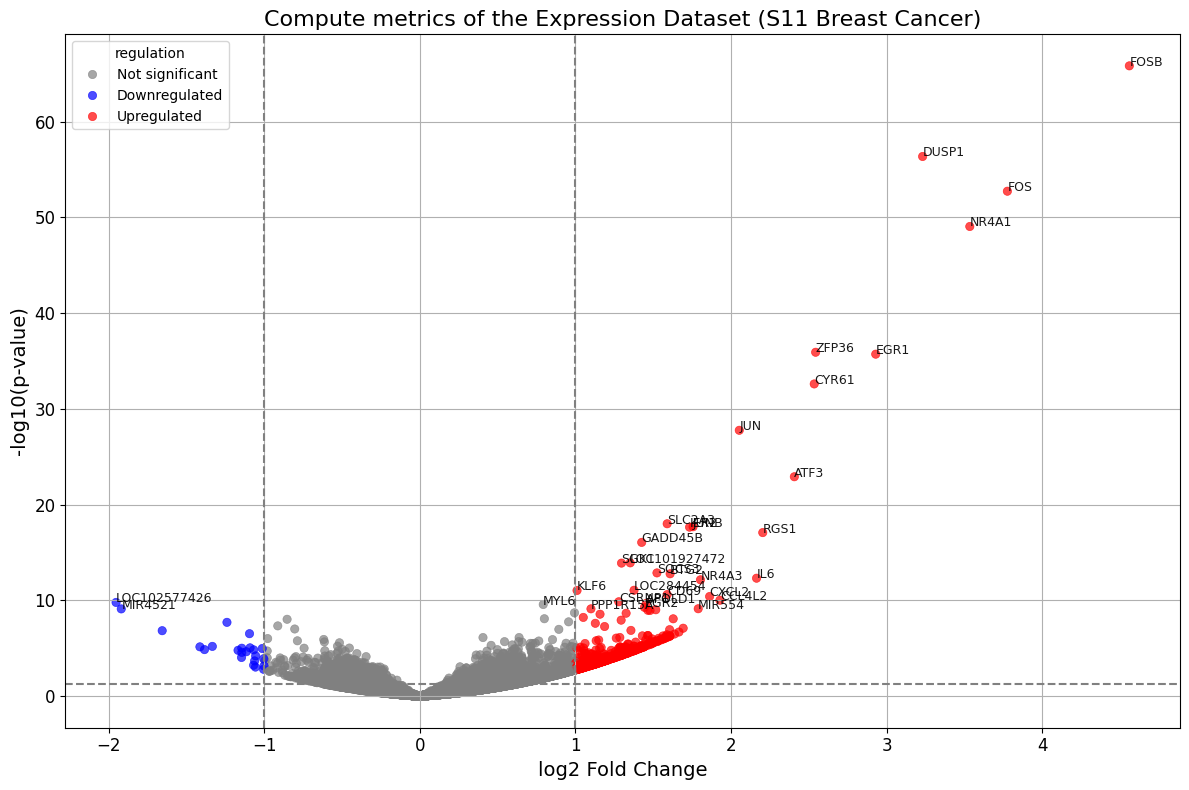

In [26]:
# Initialize the figure
plt.figure(figsize=(12, 8))

# Create the volcano plot
sns.scatterplot(data=df, x='log2fold_change', y='-log10(p_value)',
                hue='regulation', palette={'Upregulated': 'red', 'Downregulated': 'blue', 'Not significant': 'grey'},
                edgecolor=None, alpha=0.7)

# Add vertical lines for log2 fold change thresholds
plt.axvline(x=log2_fold_change_up_threshold, color='grey', linestyle='--')
plt.axvline(x=log2_fold_change_down_threshold, color='grey', linestyle='--')

# Add a horizontal line for the p-value threshold
plt.axhline(y=-np.log10(p_value_threshold), color='grey', linestyle='--')

# Customize the plot
plt.xlabel('log2 Fold Change', fontsize=14)
plt.ylabel('-log10(p-value)', fontsize=14)
plt.title('Compute metrics of the Expression Dataset (S11 Breast Cancer)', fontsize=16)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.grid(True)

# Annotate points with gene symbols
for i, row in df.iterrows():
    if row['-log10(p_value)'] > 9.1 or abs(row['log2fold_change']) > 2:
        plt.annotate(row['symbol'], 
                     (row['log2fold_change'], row['-log10(p_value)']),
                     fontsize=9, 
                     alpha=0.9)

# Show the plot
plt.tight_layout()
plt.show()

In [8]:
# Load the expression data
# expression_data = pd.read_excel(
#     "/Users/karthik/Desktop/PHCCO IISc Internship/EMT/example.xlsx",
#     sheet_name="Sheet1", header=None)

expression_data = pd.read_csv(
    '/Users/karthik/Desktop/PHCCO IISc Internship/EMT/processed_s11_expression_data.csv')

# Filter to keep only 'upregulated' and 'downregulated' rows
filtered_data = expression_data[expression_data['regulation'].isin(['Upregulated', 'Downregulated'])]

# Extract the relevant columns
filtered_data = filtered_data[['symbol', 'log2fold_change', 'regulation']]

# Convert to a dictionary with 'uniprot_id' as the key and 'log2fold_change' as the value
filtered_dict = filtered_data.set_index('symbol')['log2fold_change'].to_dict()

# Print or save the filtered upregulated data
print("Filtered Upregulated Data:")
filtered_data

Filtered Upregulated Data:


,symbol,log2fold_change,regulation
83,LOC100996583,-1.115894,Downregulated
290,PADI6,1.124748,Upregulated
316,RNF186,1.170303,Upregulated
319,PLA2G2A,1.352675,Upregulated
326,VWA5B1,1.036448,Upregulated
...,...,...,...
25359,MCF2,1.112659,Upregulated
25382,SLITRK2,1.229170,Upregulated
25410,MAGEA11,1.253783,Upregulated
25425,PASD1,1.237689,Upregulated


In [23]:
# Optionally, save to a new CSV file
filtered_data.to_csv('/Users/karthik/Desktop/PHCCO IISc Internship/EMT/filtered_processed_s11_expression.csv', index=False)

In [95]:
filtered_data = pd.read_csv('/Users/karthik/Desktop/PHCCO IISc Internship/EMT/filtered_processed_s11_expression.csv')

In [51]:
genes = []

for gene_id in model.genes:
    genes.append(gene_id.id)
    
genes

['0',
 '26_AT1',
 '314_AT1',
 '8639_AT1',
 '314_AT2',
 '1591_AT1',
 '1594_AT1',
 '10993_AT1',
 '6818_AT1',
 '89874_AT1',
 '55293_AT1',
 '3945_AT1',
 '92483_AT1',
 '160287_AT1',
 '3948_AT2',
 '3948_AT1',
 '3939_AT1',
 '134526_AT1',
 '51_AT2',
 '51_AT1',
 '95_AT1',
 '50_AT1',
 '48_AT1',
 '8309_AT1',
 '52_AT3',
 '55_AT1',
 '52_AT1',
 '52_AT2',
 '788_AT1',
 '9194_AT1',
 '55902_AT1',
 '55902_AT2',
 '9123_AT1',
 '6566_AT1',
 '57835_AT2',
 '65985_AT1',
 '8671_AT1',
 '57835_AT3',
 '438_AT1',
 '57835_AT4',
 '1571_AT1',
 '57835_AT1',
 '4967_AT2',
 '100_AT1',
 '8050_AT1',
 '1738_AT1',
 '3177_AT1',
 '4967_AT1',
 '1743_AT1',
 '126_AT1',
 '205_AT3',
 '128_AT1',
 '204_AT1',
 '130_AT1',
 '205_AT2',
 '127_AT1',
 '205_AT1',
 '131_AT1',
 '204_AT3',
 '124_AT1',
 '204_AT2',
 '125_AT1',
 '26289_AT2',
 '137872_AT1',
 '26289_AT1',
 '1312_AT2',
 '50808_AT1',
 '1312_AT1',
 '262_AT1',
 '117247_AT1',
 '222_AT1',
 '113_AT1',
 '218_AT1',
 '108_AT1',
 '220_AT1',
 '221_AT1',
 '114_AT1',
 '111_AT1',
 '3242_AT1',
 '115

In [97]:
# Keep only reactions in the model that have associated genes in your expression data
genes_in_filtered_expression_data = filtered_data.copy()['symbol'].to_list()

genes_to_keep = []
for gene_id in model.genes:
    if gene_id.name in genes_in_filtered_expression_data:
        genes_to_keep.append(gene_id.id)

In [82]:
# Test code on how to iterate over the structure of the model
rxn_ids = model.genes.get_by_id('26_AT1').reactions
rxn_ids = [rxn.id for rxn in rxn_ids]  # Extracting reaction IDs as strings

print('13DAMPPOX' in rxn_ids)

True


In [112]:
def remove_genes_and_reactions(model, genes_in_filtered_processed_expression_data):

    genes_to_remove = set()
    for gene_id in model.genes:
        if gene_id.name not in genes_in_filtered_processed_expression_data:
            genes_to_remove.add(gene_id.id)

    print(f"Genes to Remove: {genes_to_remove}")

    remove_genes(model, genes_to_remove, remove_reactions=True)
    prune_unused_metabolites(model)
    prune_unused_reactions(model)

    return model


base_model = remove_genes_and_reactions(
    model, genes_in_filtered_processed_expression_data=genes_in_filtered_expression_data
)
base_model

Genes to Remove: {'5230_AT1', '518_AT2', '93183_AT1', '1491_AT1', '283208_AT1', '6611_AT1', '56886_AT1', '204_AT1', '9517_AT1', '55650_AT1', '7385_AT1', '386757_AT1', '51703_AT1', '29926_AT2', '130013_AT1', '3101_AT1', '9394_AT1', '3028_AT1', '353_AT1', '2628_AT1', '51170_AT1', '8613_AT1', '51382_AT1', '1588_AT1', '509_AT1', '411_AT1', '276_AT1', '80704_AT1', '594_AT2', '509_AT2', '267020_AT1', '493_AT1', '5106_AT1', '3418_AT1', '10560_AT1', '124872_AT1', '27068_AT2', '57419_AT1', '1734_AT1', '6487_AT10', '51146_AT1', '9390_AT1', '4048_AT1', '178_AT5', '2171_AT1', '5294_AT1', '8372_AT1', '249_AT1', '6817_AT4', '498_AT3', '34_AT1', '3615_AT1', '25874_AT1', '154091_AT1', '5151_AT2', '55350_AT2', '645_AT1', '10165_AT1', '2760_AT1', '5281_AT1', '875_AT1', '5198_AT1', '5860_AT1', '1208_AT1', '129807_AT1', '441024_AT1', '4846_AT1', '51109_AT1', '1562_AT1', '1109_AT1', '5950_AT1', '7350_AT1', '8041_AT1', '26301_AT1', '2131_AT1', '98_AT1', '1854_AT1', '6553_AT1', '6715_AT1', '2678_AT2', '5052_

Name,Recon3D
Memory address,32a03f290
Number of metabolites,5835
Number of reactions,5376
Number of genes,74
Number of groups,0
Objective expression,1.0*BIOMASS_maintenance - 1.0*BIOMASS_maintenance_reverse_5b3f9
Compartments,"cytosol, lysosome, mitochondria, endoplasmic reticulum, extracellular space, peroxisome/glyoxysome, nucleus, golgi apparatus, inner mitochondrial compartment"


In [113]:
cobra.io.write_sbml_model(base_model, 'base_model.xml')

In [21]:
base_model = cobra.io.read_sbml_model('base_model.xml')
base_model

Name,Recon3D
Memory address,31947ce10
Number of metabolites,5835
Number of reactions,5376
Number of genes,74
Number of groups,0
Objective expression,1.0*BIOMASS_maintenance - 1.0*BIOMASS_maintenance_reverse_5b3f9
Compartments,"cytosol, lysosome, mitochondria, endoplasmic reticulum, extracellular space, peroxisome/glyoxysome, nucleus, golgi apparatus, inner mitochondrial compartment"


In [123]:
solution = base_model.optimize()
solution

,fluxes,reduced_costs
24_25DHVITD3tm,0.0,0.000000e+00
25HVITD3t,0.0,0.000000e+00
COAtl,0.0,-2.247294e-33
EX_5adtststerone_e,0.0,0.000000e+00
EX_5adtststerones_e,0.0,0.000000e+00
...,...,...
ACMPGLUTTRsc,0.0,0.000000e+00
FVSCOAhc,0.0,2.088930e-17
MDZGLChr,0.0,0.000000e+00
TMACMPhr,0.0,0.000000e+00


In [126]:
# Sampling the model
sample_size = 1000 
samples = sample(base_model, n=sample_size, processes=6)

samples_df = pd.DataFrame(samples)
samples_df

KeyboardInterrupt: 

In [10]:
def map_genes_to_reactions(model, expression_dict):
    reaction_scores = []
    
    for gene in model.genes:
        genes_reactions = gene.reactions
        expressions = expression_dict.get(gene.name, 0)
        
        for reaction in genes_reactions:
            if isinstance(expressions, list):
                if reaction.name in [entry['Reaction'] for entry in reaction_scores]:
                    # Average the expressions in case of multiple scores
                    existing_entry = next(entry for entry in reaction_scores if entry['Reaction'] == reaction.name)
                    existing_entry['Score'] = (existing_entry['Score'] + sum(expressions) / len(expressions)) / 2
                else:
                    reaction_scores.append({'Gene': gene.name,
                                            'ReactionID': reaction.id, 
                                            'Reaction': reaction.name, 
                                            'Score': sum(expressions) / len(expressions)})
            else:
                if reaction.name in [entry['Reaction'] for entry in reaction_scores]:
                    existing_entry = next(entry for entry in reaction_scores if entry['Reaction'] == reaction.name)
                    existing_entry['Score'] = (existing_entry['Score'] + expressions) / 2
                else:
                    reaction_scores.append({'Gene': gene.name, 
                                            'ReactionID': reaction.id, 
                                            'Reaction': reaction.name, 
                                            'Score': expressions})
    
    return reaction_scores

reaction_scores = map_genes_to_reactions(base_model, filtered_dict)
reaction_scores_df = pd.DataFrame(reaction_scores)
reaction_scores_df

,Gene,ReactionID,Reaction,Score
0,SLC4A4,3HCO3_NAt,Bicarbonate transport (Na/HCO3 1:3 cotransport),1.135252
1,SLC4A4,2HCO3_NAt,Bicarbonate transport (Na/HCO3 1:2 cotransport),1.135252
2,ADH7,r0739,Alcohol dehydrogenase Bile acid biosynthesis E...,1.179792
3,ADH7,ALCD22_D,Alcohol dehydrogenase (D-lactaldehyde),1.179792
4,ADH7,HMR_1129,Alcohol Dehydrogenase,1.179792
...,...,...,...,...
652,CES5A,HMR_8643,Carboxylesterase,1.023915
653,SLC22A12,HMR_9622,HMR 9622,1.027543
654,DPEP3,HMR_1085,Membrane Dipeptidase,1.201755
655,UGT2A3,HDCA24GSr,UDP-Glucuronosyltransferase (UGT) (hyodeoxycho...,1.272415


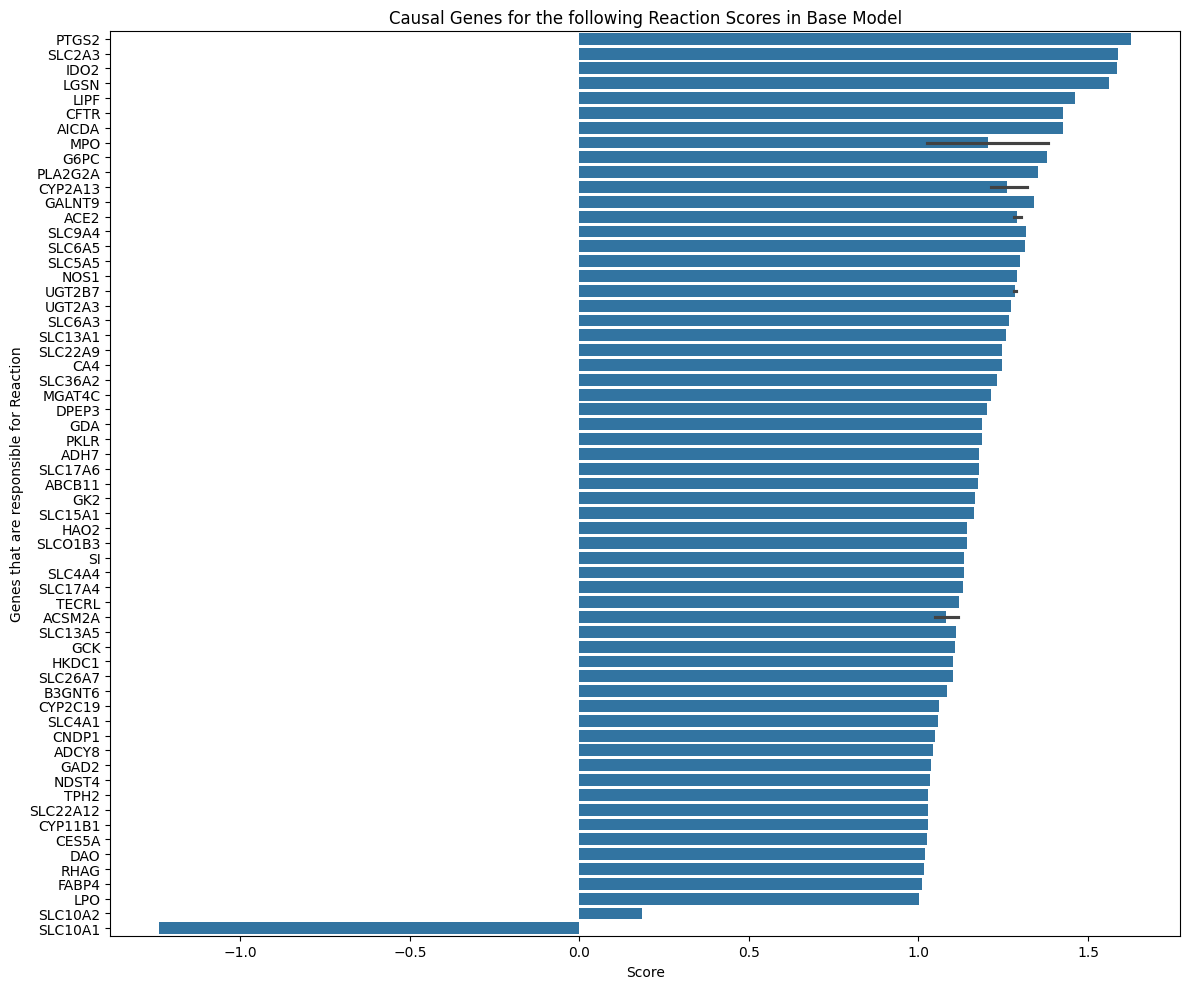

In [11]:
# Sort reaction_scores_df by 'Score' in descending order
reaction_scores_df = reaction_scores_df.sort_values(by='Score', ascending=False)

plt.figure(figsize=(12, 10))
sns.barplot(x='Score', y='Gene', data=reaction_scores_df)
plt.xlabel('Score')
plt.ylabel('Genes that are responsible for Reaction')
plt.title('Causal Genes for the following Reaction Scores in Base Model')
plt.tight_layout()
plt.show()


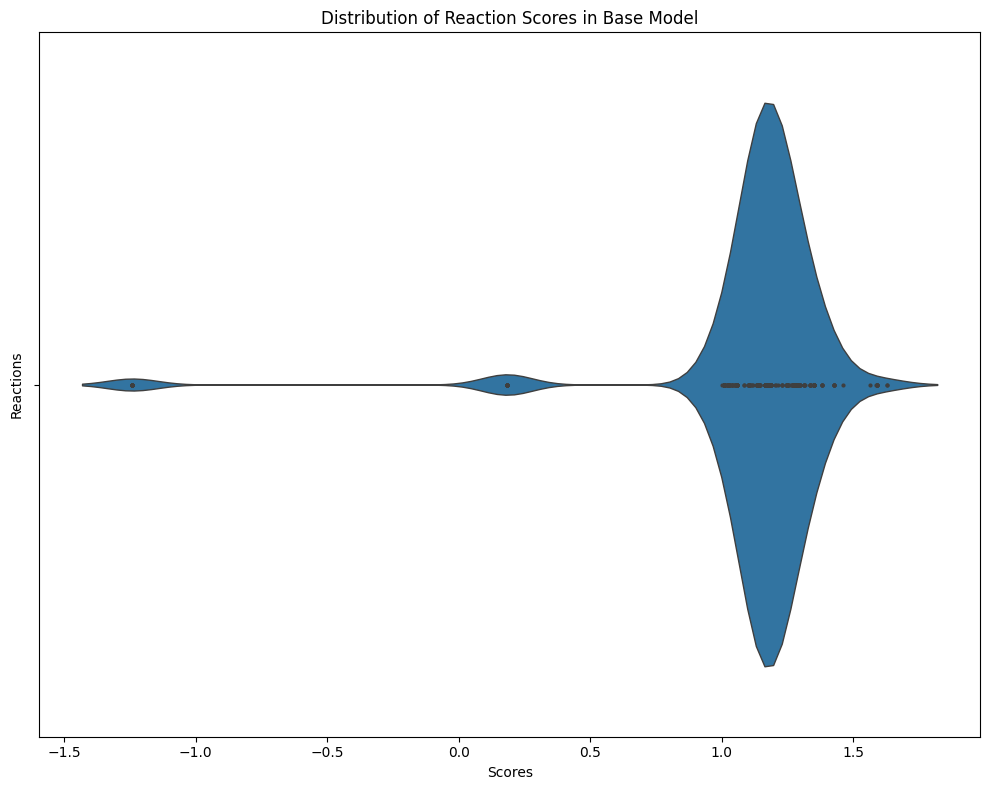

In [12]:
# Sort reactions by score
reaction_scores_df = reaction_scores_df.sort_values(by='Score', ascending=False)

# Plotting vertical violin plot
plt.figure(figsize=(10, 8))
sns.violinplot(x='Score', data=reaction_scores_df, inner='point', linewidth=1)
plt.xlabel('Scores')
plt.ylabel('Reactions')
plt.title('Distribution of Reaction Scores in Base Model')
plt.tight_layout()
plt.show()

### iMAT algorithm (Legit): 

In [22]:
# high_threshold = expression_data['expression_data'].quantile(0.75)
# low_threshold = expression_data['expression_data'].quantile(0.25)

# Set high and low expression thresholds based on mean and standard deviation
# High expression = top 10%

# Apply iMAT
# NOTE: iMAT with IQR for calculating threshold gives number of high expressed genes, around 100 among ~600
# NOTE: iMAT with mean + or - std threshold gives number of high expressed genes: 2 out of ~600!! So i rejected it.

def apply_imat(model, reaction_scores, expression_data):
    
    high_threshold = expression_data['log2fold_change'].quantile(0.75)
    low_threshold = expression_data['log2fold_change'].quantile(0.25)
    
    # mean_expression = expression_data['log2fold_change'].mean()
    # std_expression = expression_data['log2fold_change'].std()

    # high_threshold = mean_expression + std_expression
    # low_threshold = mean_expression - std_expression
    
    # Get reaction IDs based on high and low expression thresholds
    high_expression_reactions = reaction_scores_df[reaction_scores_df['Score'] >= high_threshold]['ReactionID']
    low_expression_reactions = reaction_scores_df[reaction_scores_df['Score'] <= low_threshold]['ReactionID']
    
    print(f"High expressed: {len(high_expression_reactions)}")
    print(f"Low expressed: {len(low_expression_reactions)}")
    
    print(f"Gene Count in IQR: {reaction_scores_df['ReactionID'].count()}")
    
    for rxn_id in high_expression_reactions:
        model.reactions.get_by_id(rxn_id).lower_bound = 0
    
    for rxn_id in low_expression_reactions:
        model.reactions.get_by_id(rxn_id).upper_bound = 0

    return model

integrated_model = apply_imat(base_model, reaction_scores, filtered_data)
print("Model integrated with the expression data")

High expressed: 103
Low expressed: 93
Gene Count in IQR: 657
Model integrated with the expression data


In [24]:
# Each reaction carried out in steady state conditions
fva_result_base_model = flux_variability_analysis(base_model, fraction_of_optimum=0.9)
fva_result_integrated_model = flux_variability_analysis(integrated_model, fraction_of_optimum=0.9)

# Save the FVA results
fva_result_base_model.to_csv('fva_base_model.csv')
fva_result_integrated_model.to_csv('fva_integrated_model.csv')

In [33]:
fva_result_base_model = pd.read_csv('fva_base_model.csv')
fva_result_integrated_model = pd.read_csv('fva_integrated_model.csv')

# Rename the first unnamed column
fva_result_base_model_df = fva_result_base_model.rename(columns={fva_result_base_model.columns[0]: 'ReactionID'})
fva_result_integrated_model_df = fva_result_integrated_model.rename(columns={fva_result_integrated_model.columns[0]: 'ReactionID'})
print(fva_result_base_model_df)

               ReactionID  minimum       maximum
0          24_25DHVITD3tm      0.0  0.000000e+00
1               25HVITD3t      0.0  1.000000e+03
2                   COAtl      0.0  0.000000e+00
3      EX_5adtststerone_e      0.0  0.000000e+00
4     EX_5adtststerones_e      0.0  0.000000e+00
...                   ...      ...           ...
5371         ACMPGLUTTRsc      0.0  1.000000e+03
5372             FVSCOAhc      0.0  0.000000e+00
5373             MDZGLChr      0.0  1.325805e-13
5374             TMACMPhr      0.0  0.000000e+00
5375           CYSACMPitr      0.0  1.000000e+03

[5376 rows x 3 columns]


In [35]:
# Combine the results
fva_combined = pd.merge(fva_result_base_model_df, fva_result_integrated_model_df, on='ReactionID', suffixes=('_base_model', '_integrated_model'))
print(fva_combined)
fva_combined.to_csv('fva_combined.csv', index=False)

               ReactionID  minimum_base_model  maximum_base_model  \
0          24_25DHVITD3tm                 0.0        0.000000e+00   
1               25HVITD3t                 0.0        1.000000e+03   
2                   COAtl                 0.0        0.000000e+00   
3      EX_5adtststerone_e                 0.0        0.000000e+00   
4     EX_5adtststerones_e                 0.0        0.000000e+00   
...                   ...                 ...                 ...   
5371         ACMPGLUTTRsc                 0.0        1.000000e+03   
5372             FVSCOAhc                 0.0        0.000000e+00   
5373             MDZGLChr                 0.0        1.325805e-13   
5374             TMACMPhr                 0.0        0.000000e+00   
5375           CYSACMPitr                 0.0        1.000000e+03   

      minimum_integrated_model  maximum_integrated_model  
0                          0.0              0.000000e+00  
1                          0.0              1.000000e

In [36]:
# Calculate the differences
fva_combined['minimum_flux_diff'] = fva_combined['minimum_integrated_model'] - fva_combined['minimum_base_model']
fva_combined['maximum_flux_diff'] = fva_combined['maximum_integrated_model'] - fva_combined['maximum_base_model']
fva_combined


,ReactionID,minimum_base_model,maximum_base_model,minimum_integrated_model,maximum_integrated_model,minimum_flux_diff,maximum_flux_diff
0,24_25DHVITD3tm,0.0,0.000000e+00,0.0,0.000000e+00,0.0,0.0
1,25HVITD3t,0.0,1.000000e+03,0.0,1.000000e+03,0.0,0.0
2,COAtl,0.0,0.000000e+00,0.0,0.000000e+00,0.0,0.0
3,EX_5adtststerone_e,0.0,0.000000e+00,0.0,0.000000e+00,0.0,0.0
4,EX_5adtststerones_e,0.0,0.000000e+00,0.0,0.000000e+00,0.0,0.0
...,...,...,...,...,...,...,...
5371,ACMPGLUTTRsc,0.0,1.000000e+03,0.0,1.000000e+03,0.0,0.0
5372,FVSCOAhc,0.0,0.000000e+00,0.0,0.000000e+00,0.0,0.0
5373,MDZGLChr,0.0,1.325805e-13,0.0,1.325805e-13,0.0,0.0
5374,TMACMPhr,0.0,0.000000e+00,0.0,0.000000e+00,0.0,0.0


In [ ]:
# Perform t-test
t_stat, p_value = ttest_ind(fva_combined['minimum_flux_diff'], fva_combined['maximum_flux_diff'])
fva_combined['p_value'] = p_value
fva_combined

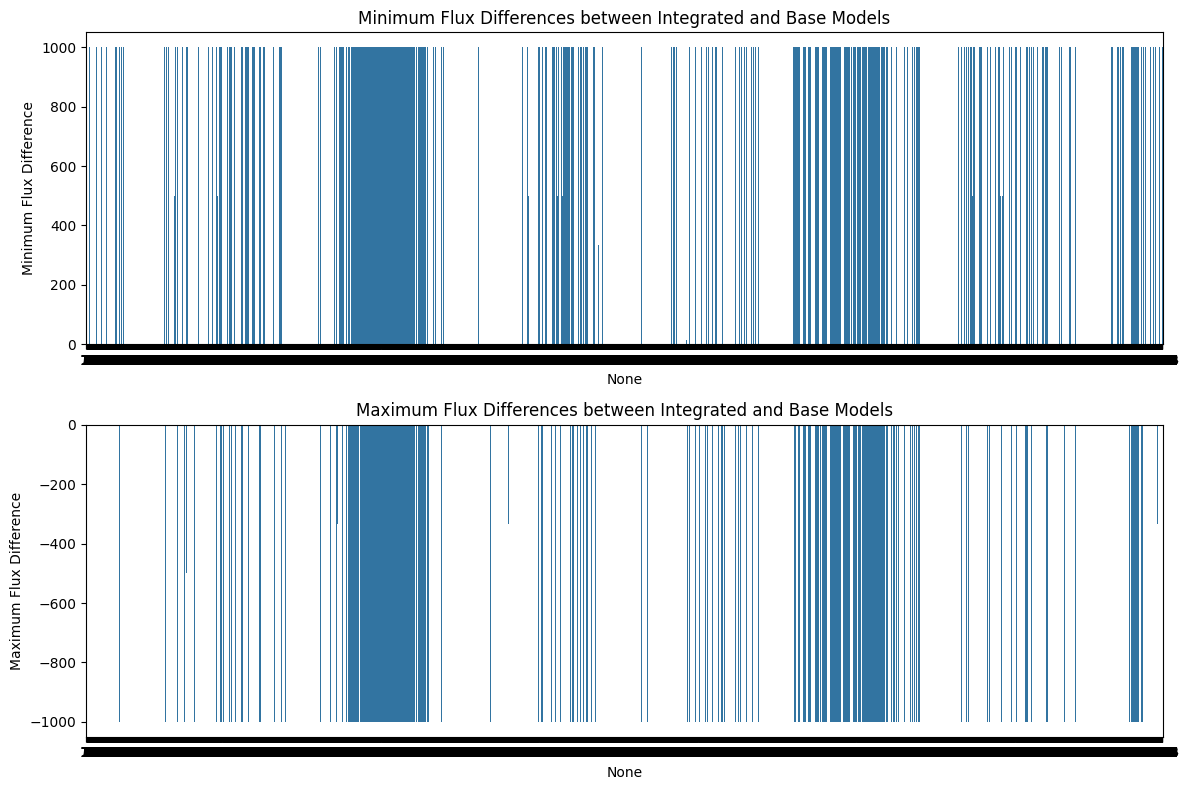

In [39]:
# Plotting the differences
plt.figure(figsize=(12, 8))

# Plot minimum flux differences
plt.subplot(2, 1, 1)
sns.barplot(x=fva_combined.index, y='maximum_base_model', data=fva_combined)
plt.axhline(0, color='gray', linewidth=0.5)
plt.ylabel('Minimum Flux Difference')
plt.title('Minimum Flux Differences between Integrated and Base Models')

# Plot maximum flux differences
plt.subplot(2, 1, 2)
sns.barplot(x=fva_combined.index, y='minimum_integrated_model', data=fva_combined)
plt.axhline(0, color='gray', linewidth=0.5)
plt.ylabel('Maximum Flux Difference')
plt.title('Maximum Flux Differences between Integrated and Base Models')

plt.tight_layout()
plt.show()

In [ ]:
# Calculate -log10(p-value)
pathway_p_values['-log10(p-value)'] = -np.log10(pathway_p_values['p_value'])

# Plot with Seaborn
plt.figure(figsize=(10, 6))
sns.barplot(x='-log10(p-value)', y='pathway', data=pathway_p_values, palette='viridis')
plt.title('-log10(p-value) for Pathways')
plt.xlabel('-log10(p-value)')
plt.ylabel('Pathway')
plt.tight_layout()
plt.show()

#### Add `status` column to the `imat_fva_results.csv` file, to later check which reactions are active and rename the first column to `reaction`

In [9]:
fva_result = pd.read_csv('/Users/karthik/Desktop/PHCCO IISc Internship/EMT/imat_fva_results.csv')
fva_result.head()

,Unnamed: 0,minimum,maximum
0,24_25DHVITD3tm,0.0,0.1
1,25HVITD3t,0.0,0.1
2,COAtl,0.0,0.1
3,EX_5adtststerone_e,-0.1,0.1
4,EX_5adtststerones_e,-0.3,0.1


In [11]:
# Rename the first column to 'reaction'
fva_result.rename(columns={fva_result.columns[0]: 'reaction'}, inplace=True)

# Initialize all as inactive
fva_result['status'] = 'Inactive'

# Update status based on flux bounds
fva_result.loc[(fva_result['minimum'] < 0) & (fva_result['maximum'] > 0), 'status'] = 'Active'
fva_result.loc[(fva_result['minimum'] == 0) & (fva_result['maximum'] == 0), 'status'] = 'Inactive'
fva_result.loc[((fva_result['minimum'] == 0) & (fva_result['maximum'] < 0)) | 
                ((fva_result['minimum'] > 0) & (fva_result['maximum'] == 0)), 'status'] = 'SemiActive'

print(fva_result)

                  reaction       minimum  maximum    status
0           24_25DHVITD3tm  0.000000e+00      0.1  Inactive
1                25HVITD3t  0.000000e+00      0.1  Inactive
2                    COAtl  0.000000e+00      0.1  Inactive
3       EX_5adtststerone_e -1.000000e-01      0.1    Active
4      EX_5adtststerones_e -3.000000e-01      0.1    Active
...                    ...           ...      ...       ...
10595         ACMPGLUTTRsc  0.000000e+00      0.1  Inactive
10596             FVSCOAhc  0.000000e+00      0.1  Inactive
10597             MDZGLChr  0.000000e+00      0.1  Inactive
10598             TMACMPhr  0.000000e+00      0.1  Inactive
10599           CYSACMPitr  1.030764e-15      0.1  Inactive

[10600 rows x 4 columns]


In [12]:
fva_result.to_csv('imat_fva_results.csv', index=False)

In [16]:
# Filter reactions based on activity (adjust based on your CSV structure)
active_epithelial = fva_result[fva_result['status'] == 'Active']['reaction']
active_hybrid = fva_result[fva_result['status'] == 'Active']['reaction']
active_mesenchymal = fva_result[fva_result['status'] == 'Active']['reaction']

print("Active Epithelial: \n", active_epithelial)
print("Active Hybrid: \n", active_hybrid)
print("Active Mesenchymal: \n", active_mesenchymal)

Active Epithelial: 
 3         EX_5adtststerone_e
4        EX_5adtststerones_e
7                 EX_5mthf_e
8                  EX_5thf_e
9                  EX_6dhf_e
                ...         
10558                3DHLCAt
10585           PROFVSCOAitx
10586            PTVSTLACitr
10592             TLACFVSitr
10593               TMDM1itr
Name: reaction, Length: 3668, dtype: object
Active Hybrid: 
 3         EX_5adtststerone_e
4        EX_5adtststerones_e
7                 EX_5mthf_e
8                  EX_5thf_e
9                  EX_6dhf_e
                ...         
10558                3DHLCAt
10585           PROFVSCOAitx
10586            PTVSTLACitr
10592             TLACFVSitr
10593               TMDM1itr
Name: reaction, Length: 3668, dtype: object
Active Mesenchymal: 
 3         EX_5adtststerone_e
4        EX_5adtststerones_e
7                 EX_5mthf_e
8                  EX_5thf_e
9                  EX_6dhf_e
                ...         
10558                3DHLCAt
10585      

In [ ]:
# Create context-specific models
epithelial_model = model.copy()
hybrid_model = model.copy()
mesenchymal_model = model.copy()

# Set bounds based on active reactions
for reaction in epithelial_model.reactions:
    if reaction.id not in active_epithelial:
        reaction.lower_bound = 0.0
        reaction.upper_bound = 0.0

for reaction in hybrid_model.reactions:
    if reaction.id not in active_hybrid:
        reaction.lower_bound = 0.0
        reaction.upper_bound = 0.0

for reaction in mesenchymal_model.reactions:
    if reaction.id not in active_mesenchymal:
        reaction.lower_bound = 0.0
        reaction.upper_bound = 0.0

cobra.io.write_sbml_model(epithelial_model, 'epithelial_model.xml')
cobra.io.write_sbml_model(hybrid_model, 'hybrid_model.xml')
cobra.io.write_sbml_model(mesenchymal_model, 'mesenchymal_model.xml')

### iMAT:

In [ ]:
# Define epithelial and mesenchymal gene sets
epithelial_genes = ['CDH1', 'EPCAM', 'OCLN', 'CLDN1', 'KRT8', 'KRT18', 'DSG3', 'MUC1', 'JUP', 'SPINT2', 'GATA3', 'GRHL2', 'SFN', 'CRB3']
mesenchymal_genes = ['VIM', 'FN1', 'CDH2', 'SNAI1', 'SNAI2', 'TWIST1', 'ZEB1', 'ZEB2', 'MMP2', 'MMP9', 'NID1', 'COL1A1', 'COL3A1', 'THY1']


### Mapping Genes to Reactions:
GPR rules in the model for mapping genes/proteins to their corresponding reactions.

In [33]:
# Map genes to reactions
def map_genes_to_reactions(gene_list, expression_dict, model):
    reaction_ids = []
    for reaction in model.reactions:
        for gene in reaction.genes:
            gene_id = gene.id
            if gene_id in gene_list and gene_id in expression_dict:
                reaction_ids.append(reaction.id)
    return list(set(reaction_ids))

epithelial_rxns = map_genes_to_reactions(epithelial_genes, expression_dict, model)
mesenchymal_rxns = map_genes_to_reactions(mesenchymal_genes, expression_dict, model)

### Defining Constraints:
1. **High Expression:** For reactions associated with highly expressed genes, set a lower bound for the flux.
2. **Low Expression:** For reactions associated with lowly expressed genes, set an upper bound for the flux.
3. **Medium Expression:** Reactions associated with medium expression genes are not constrained.

In [34]:
# Apply constraints
for rxn_id in epithelial_rxns:
    model.reactions.get_by_id(rxn_id).lower_bound = 0.1

for rxn_id in mesenchymal_rxns:
    model.reactions.get_by_id(rxn_id).upper_bound = 0.1

### Optimisation:

**Objective:** Maximize the sum of fluxes through reactions associated with highly expressed genes minus the sum of fluxes through reactions associated with lowly expressed genes.

**Constraints:** flux bounds

In [38]:
# Define the new objective function
objective_coefficients = {}

for rxn_id in epithelial_rxns:
    objective_coefficients[rxn_id] = 1.0

for rxn_id in mesenchymal_rxns:
    objective_coefficients[rxn_id] = -1.0

# Set the objective
for rxn_id, coefficient in objective_coefficients.items():
    model.reactions.get_by_id(rxn_id).objective_coefficient = coefficient

# Solve the model
solution = pfba(model)
print(f"Objective value: {solution.objective_value}")

# Save the flux distribution
fluxes = solution.fluxes
fluxes.to_csv('imat_fluxes.csv')

276649.8654639972


### Context Specific Models:

- Using Gene sets specific to epithelial and mesenchymal phenotypes.
- Apply iMAT separately using the specific gene sets for epithelial and mesenchymal models.